# Social Network Analysis — Twitch Gamers
### Part 1 (Exploratory Data Analysis) & Part 2 (Community Detection)

**Dataset:** Twitch Gamers mutual-follow network (Rozemberczki & Sarkar, 2021) — **168,114 nodes**, **6,797,557 edges**. Each node is a streamer with attributes: views, language, lifetime, affiliate status, churn (dead account), mature flag.

**How to run:** execute top-to-bottom from the project root. Requires the `src/` package and `twitch_gamers/` data. Engine is **python-igraph** (C core) — networkx is too slow/memory-heavy at 6.8M edges.

**Reproducibility note:** Part 1 metrics are deterministic. Louvain processes nodes in randomised order, so community *count* varies run-to-run while modularity *Q* stays stable (~0.42, shown below).

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.data_loader import load_features, load_graph_cached, set_seed, PROJECT_ROOT
FIG = PROJECT_ROOT / "results" / "figures"
TAB = PROJECT_ROOT / "results" / "tables"
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 20)

## Data loading & graph construction

`load_graph_cached()` builds an undirected, simplified igraph graph with vertices in `numeric_id` order, so structural metrics align row-for-row with the features table. Two correctness assertions run on first build: vertex count == 168,114 and global transitivity ≈ 0.0184 (the dataset README value).

In [2]:
features = load_features()
graph = load_graph_cached()
print(graph.summary())
features.head()

IGRAPH U--- 168114 6797557 -- 


,views,mature,life_time,created_at,updated_at,numeric_id,dead_account,language,affiliate,log_views
0,7879,1,969,2016-02-16,2018-10-12,0,0,EN,1,8.972083
1,500,0,2699,2011-05-19,2018-10-08,1,0,EN,0,6.216606
2,382502,1,3149,2010-02-27,2018-10-12,2,0,EN,1,12.854492
3,386,0,1344,2015-01-26,2018-10-01,3,0,EN,0,5.958425
4,2486,0,1784,2013-11-22,2018-10-11,4,0,EN,0,7.818832


We compute the three per-node structural metrics once and reuse them across the EDA.

In [3]:
degree = np.array(graph.degree())
pagerank = np.array(graph.pagerank())
local_clustering = np.array(graph.transitivity_local_undirected(mode="zero"))
metrics = features.copy()
metrics["degree"] = degree
metrics["pagerank"] = pagerank
metrics["local_clustering"] = local_clustering
metrics[["degree", "pagerank", "local_clustering"]].describe()

,degree,pagerank,local_clustering
count,168114.000000,1.681140e+05,168114.000000
mean,80.868423,5.948345e-06,0.159925
std,314.162731,2.157020e-05,0.139874
min,1.000000,9.323608e-07,0.000000
25%,13.000000,1.806995e-06,0.075000
50%,32.000000,3.042096e-06,0.131255
75%,75.000000,5.572789e-06,0.204678
max,35279.000000,2.925220e-03,1.000000


# Part 1 — Exploratory Data Analysis

## 1.1 Degree distribution & power-law fit

We fit a power law to the degree sequence (`powerlaw`, discrete), report exponent **α**, and compare against a lognormal alternative so we don't over-claim *scale-free* on a merely heavy-tailed distribution.

/home/ltkien/Development/CourseHomework/practice-of-social-media-analytics/final-project/.venv/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution lognormal.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


,value
alpha,2.5437
xmin,250
ks_distance,0.0051
loglik_ratio_vs_lognormal,-0.1867
loglik_p,0.8519
max_degree,35279
mean_degree,80.87
scale_free,True


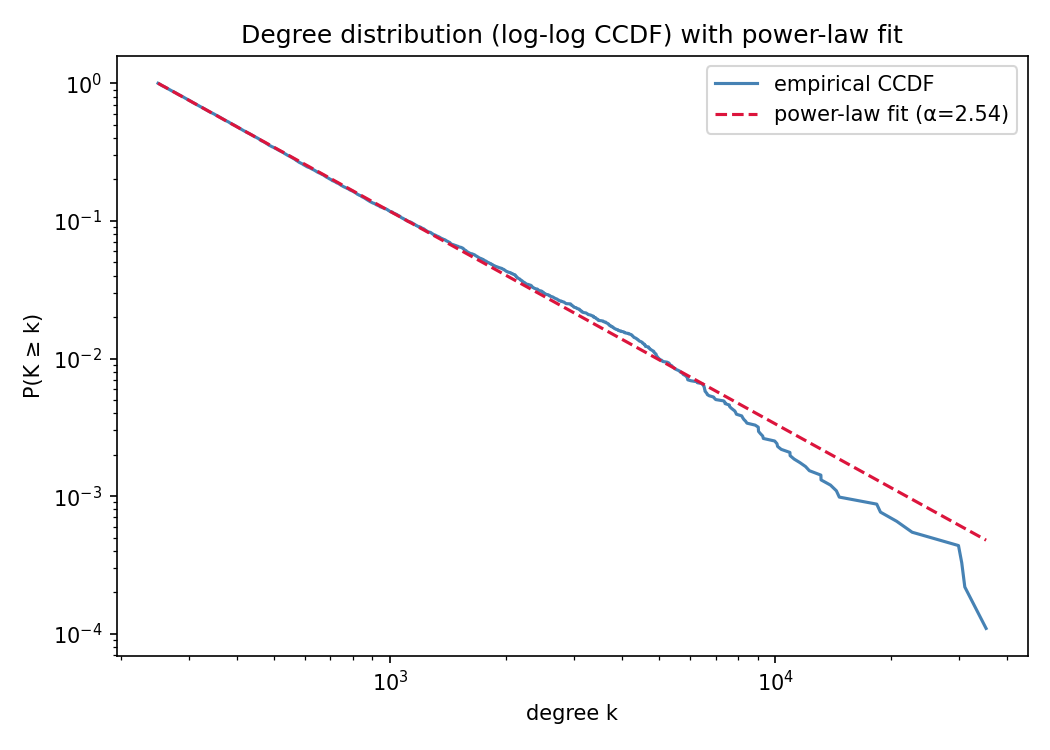

In [4]:
from src.part1_eda.degree_powerlaw import analyze_degree_powerlaw
deg_res = analyze_degree_powerlaw(metrics["degree"].to_numpy(), FIG)
display(pd.Series(deg_res).to_frame("value"))
display(Image(filename=str(FIG / "p1_degree_powerlaw_ccdf.png")))

**Reading:** α ≈ 2.5 sits in the canonical scale-free band (2, 3) and the power law is *not* significantly beaten by lognormal (large p). Honest verdict: **heavy-tailed, consistent with scale-free in the tail** — we avoid claiming a strictly scale-free network because the power-law-vs-lognormal test is not decisive.

## 1.2 Clustering & transitivity

Global transitivity (closed-triplet fraction) and the average local clustering coefficient, contextualised against a random-graph baseline.

,value
global_transitivity,0.018400
avg_local_clustering,0.159900
density,0.000481
random_baseline_clustering,0.000481
clustering_vs_random_ratio,38.200000


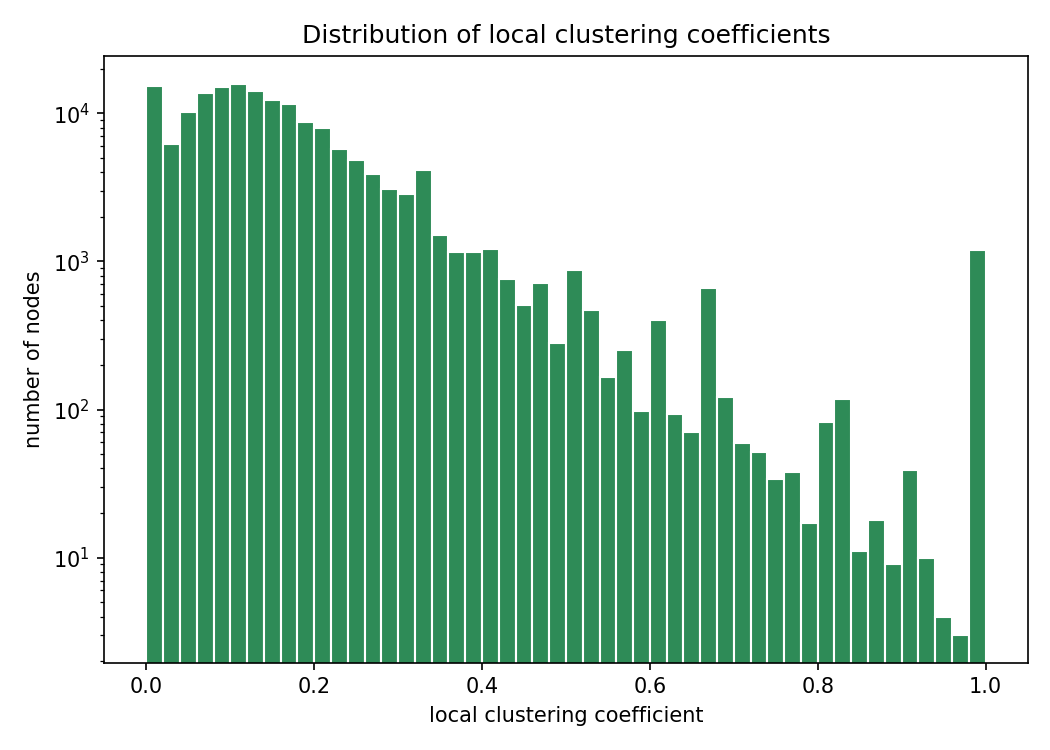

In [5]:
from src.part1_eda.clustering_transitivity import analyze_clustering
clu_res = analyze_clustering(graph, local_clustering, FIG)
display(pd.Series(clu_res).to_frame("value"))
display(Image(filename=str(FIG / "p1_local_clustering_hist.png")))

**Reading:** global transitivity 0.0184 looks tiny, but density is ~0.0005, so an Erdős–Rényi random graph of the same density would cluster at ≈ density. The observed value is **~38× the random baseline** → genuine local structure despite the sparse graph.

## 1.3 Node feature distributions

Language mix, affiliate rate, churn (dead-account) rate, view count (log scale, heavy-tailed) and account lifetime.

,value
affiliate_rate,0.4851
churn_rate,0.0307
mature_rate,0.4701
n_languages,21
dominant_language,EN
dominant_language_share,0.74
median_views,4117
median_life_time,1540


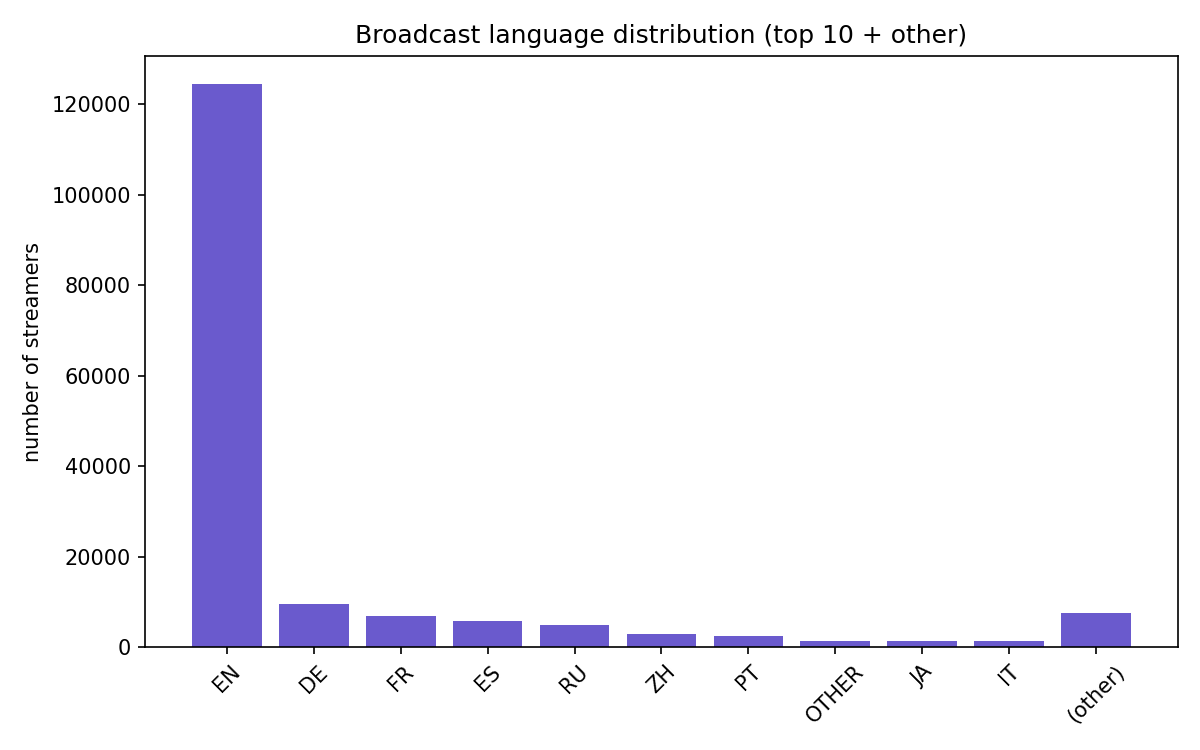

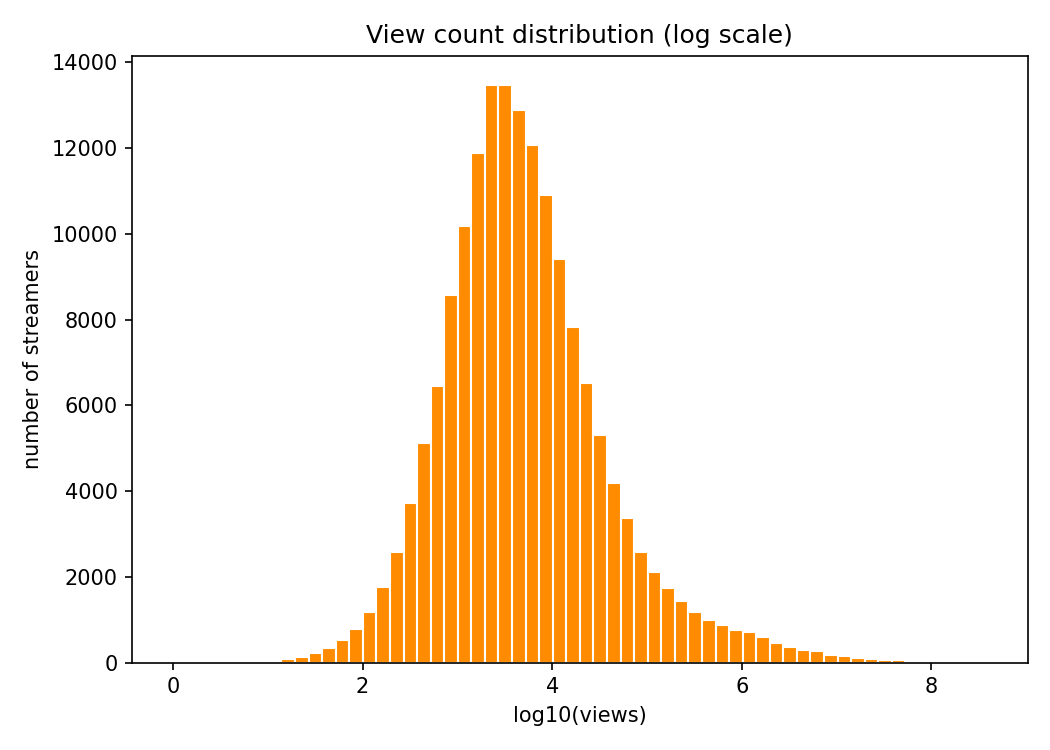

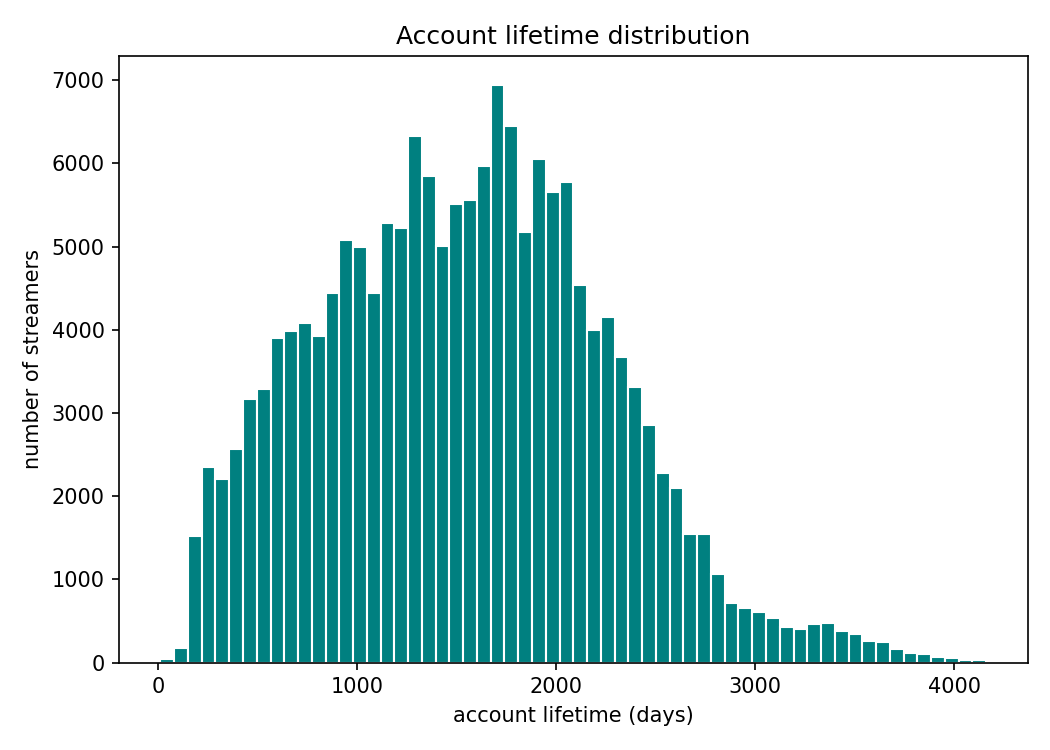

In [6]:
from src.part1_eda.feature_distributions import analyze_feature_distributions
feat_res = analyze_feature_distributions(features, FIG, TAB)
display(pd.Series(feat_res).to_frame("value"))
display(Image(filename=str(FIG / "p1_language_distribution.png")))
display(Image(filename=str(FIG / "p1_views_hist.png")))
display(Image(filename=str(FIG / "p1_lifetime_hist.png")))

**Reading:** the network is heavily English-dominated (EN ≈ 74% of nodes, 21 languages total). About half the streamers are affiliates; churn is low (~3%). Views are strongly right-skewed — hence the log scale.

## 1.4 Correlation: structural features vs node attributes

Spearman (rank) correlation is the headline because degree/PageRank/views are heavy-tailed; Pearson is shown for completeness.

,value
strongest_pair,pagerank ~ log_views
strongest_spearman,0.5515
degree_logviews_spearman,0.5144
pagerank_affiliate_spearman,0.239


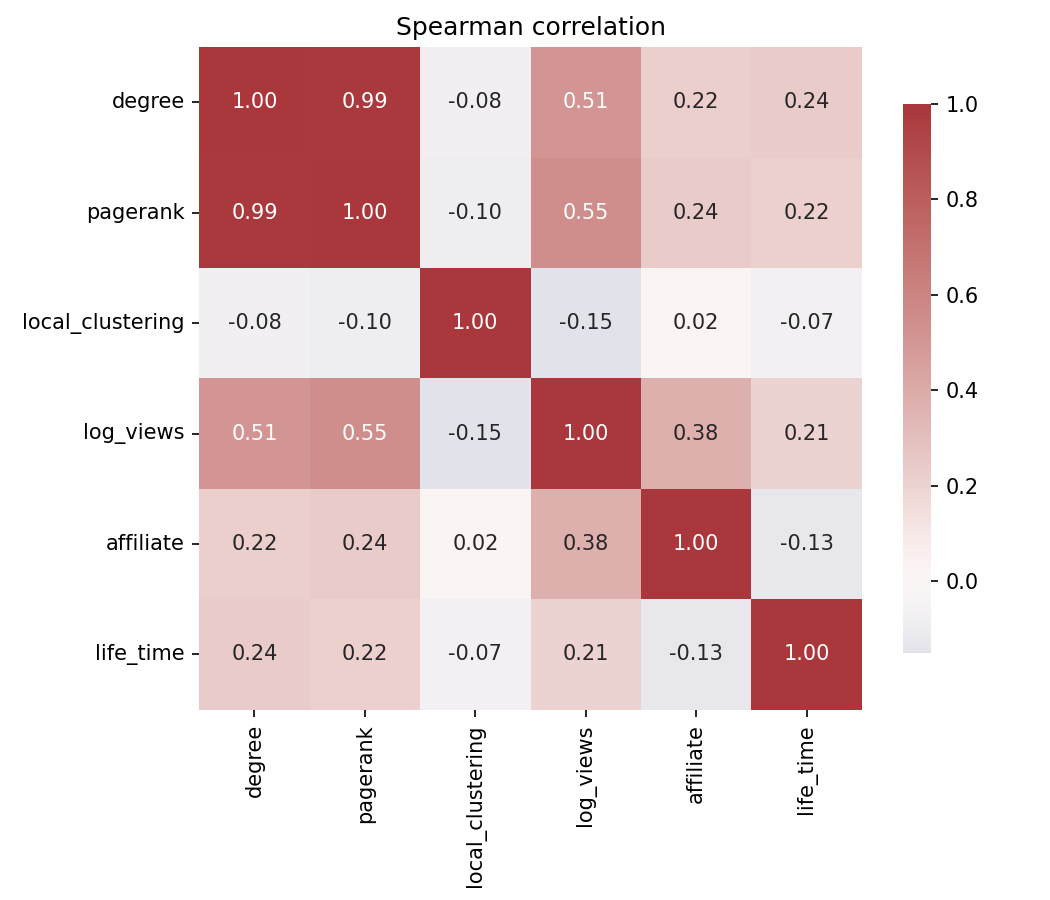

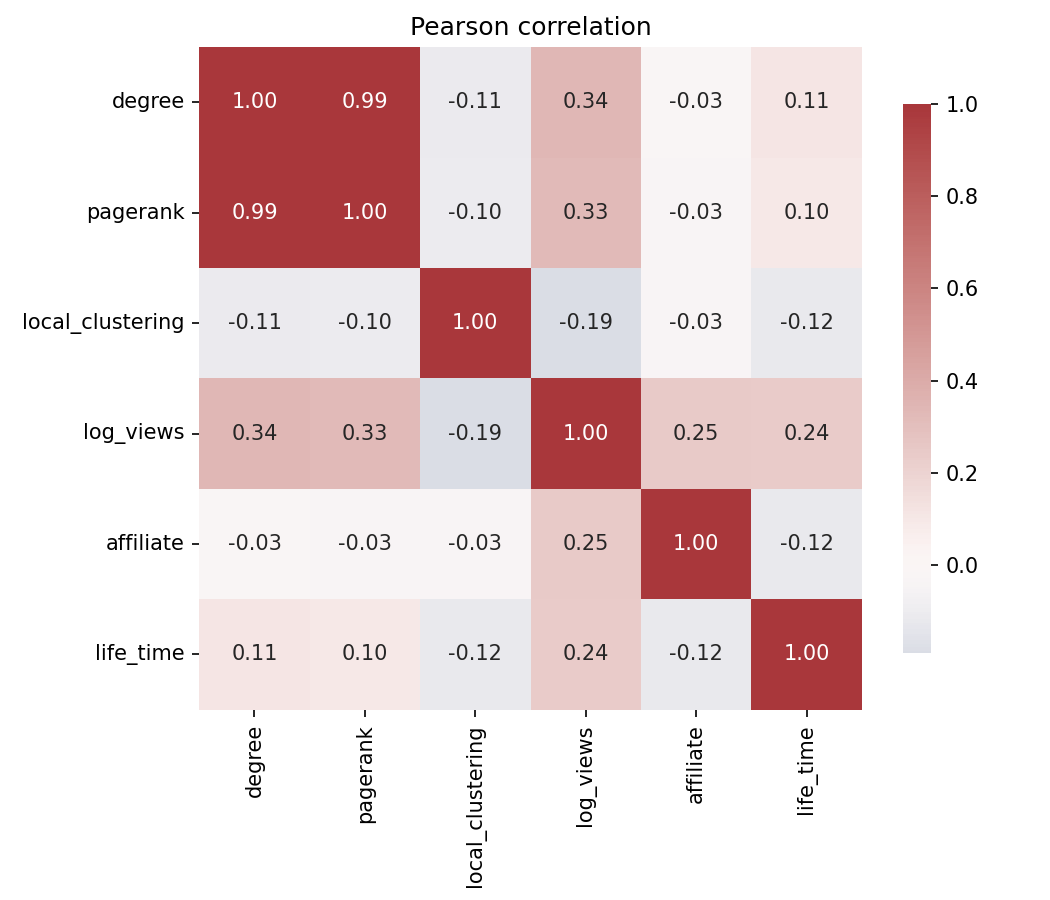

In [7]:
from src.part1_eda.correlation_analysis import analyze_correlation
corr_res = analyze_correlation(metrics, FIG, TAB)
display(pd.Series(corr_res).to_frame("value"))
display(Image(filename=str(FIG / "p1_correlation_spearman.png")))
display(Image(filename=str(FIG / "p1_correlation_pearson.png")))

**Reading:** the strongest structural↔attribute link is PageRank ~ log(views) (Spearman ≈ 0.55) — central nodes tend to be more-viewed streamers. Affiliate status correlates weakly with structural position.

# Part 2 — Community Detection

## 2.1 Louvain communities

igraph's multilevel (Louvain) algorithm maximises modularity. We report the modularity score **Q**, the size distribution, and a 3-run stability check on Q.

,value
modularity_q,0.4228
n_communities,23
largest_community,47341
median_community_size,2005
n_singletons,0
q_runs,"[0.4228, 0.4226, 0.422]"
q_std,0.00034
n_communities_runs,"[23, 24, 22]"


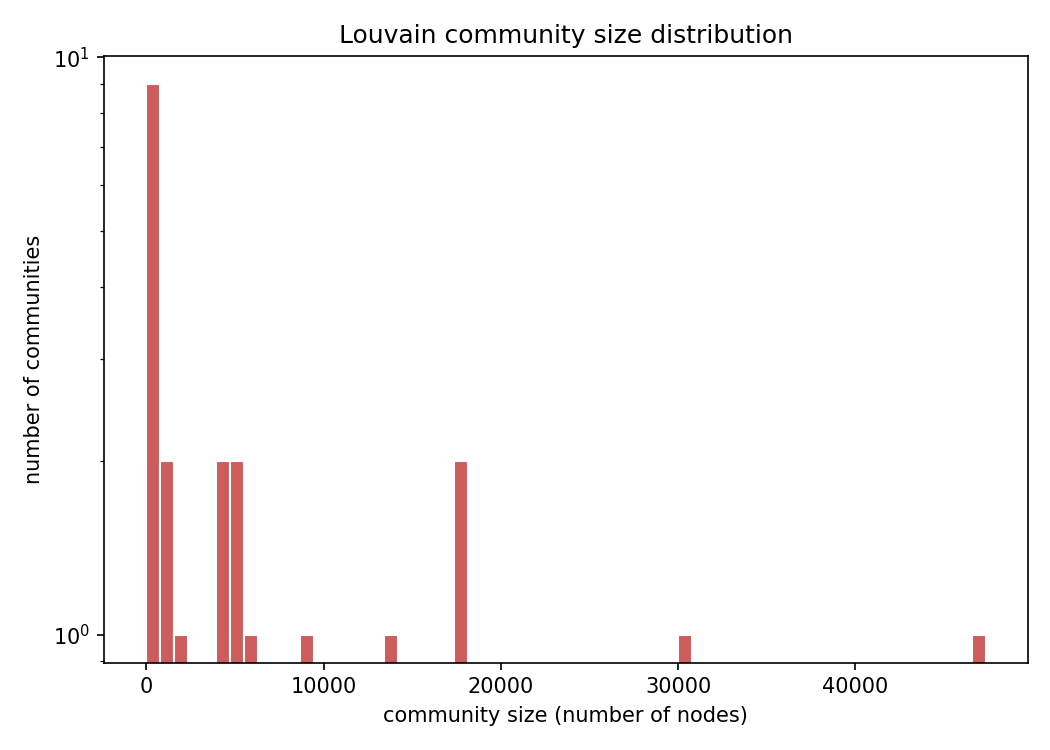

In [8]:
set_seed(42)  # reproducible Part 2 numbers run-to-run
from src.part2_community.louvain_detection import detect_communities
louvain = detect_communities(graph, FIG)
membership = louvain["membership"]
display(pd.Series(louvain["stats"]).to_frame("value"))
display(Image(filename=str(FIG / "p2_community_sizes.png")))

**Reading:** Q ≈ 0.42 (>0.3 indicates real community structure) and is stable across runs (std ~0.003), so it is not a single-run artefact.

## 2.2 Major community profiles

For the 10 largest communities: size, dominant language, **language purity** (share of the dominant language), affiliate rate, and median views.

Top-10 communities cover 93.2% of nodes; mean language purity = 90.3%


,community,size,dominant_language,language_purity,affiliate_rate,median_views
0,1,47341,EN,0.9050,0.4383,3090
1,3,29994,EN,0.9775,0.5592,5087
2,7,18020,EN,0.9074,0.4340,4617
3,2,17430,EN,0.9283,0.3128,2347
4,0,14086,EN,0.9686,0.7680,3797
5,9,8829,DE,0.9494,0.5140,6572
6,4,6255,FR,0.9584,0.5209,6094
7,5,5077,ZH,0.5395,0.3551,12274
8,10,5050,ES,0.9550,0.5307,4817
9,6,4644,RU,0.9462,0.4388,11269


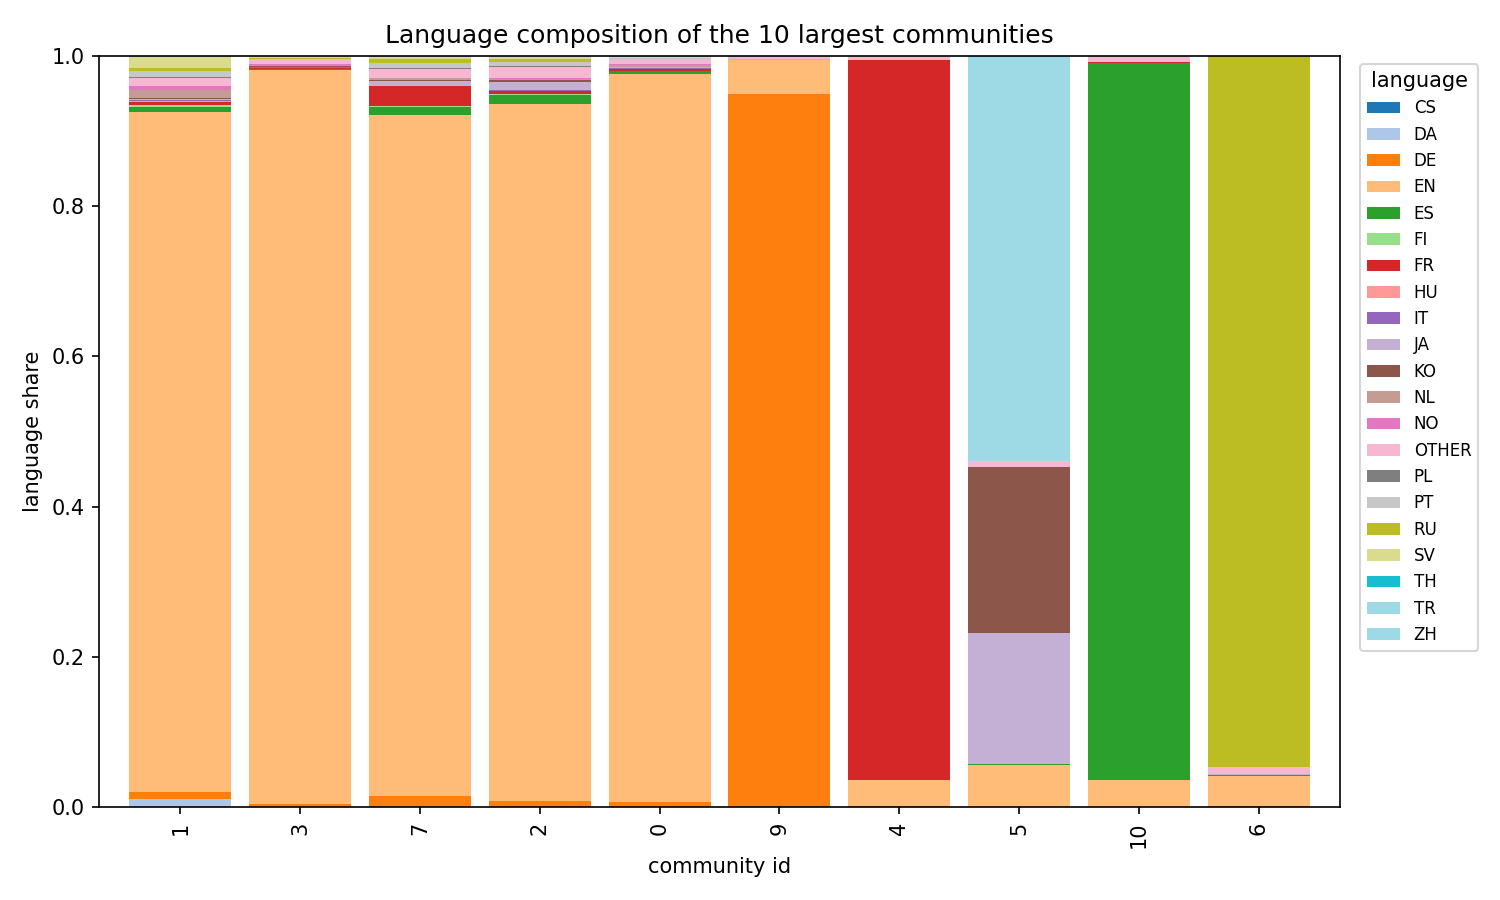

In [9]:
from src.part2_community.community_profiling import profile_communities
prof = profile_communities(features, membership, FIG, TAB)
print(f"Top-10 communities cover {prof['top_n_coverage']:.1%} of nodes; "
      f"mean language purity = {prof['mean_purity_topn']:.1%}")
display(prof["profile"])
display(Image(filename=str(FIG / "p2_language_composition.png")))

**Reading:** the largest communities are all English (English splits into several communities by non-language factors), while DE / FR / ZH / ES / RU each form their own high-purity community — the first hint that language matters but doesn't fully explain the structure.

## 2.3 NMI: communities vs language

Normalized Mutual Information between the Louvain partition and the language labels, with a random baseline for context.

In [10]:
from src.part2_community.nmi_evaluation import evaluate_nmi
nmi = evaluate_nmi(features, membership)
display(pd.Series(nmi).to_frame("value"))

,value
nmi_community_language,0.4786
nmi_random_baseline,0.0007
verdict,partially organised by language


**Reading:** NMI ≈ 0.48 (vs ~0 random baseline) → the network is **partially organised by language**: language strongly defines the smaller non-English communities, but the dominant English population is organised by other factors.

## 2.4 Community quality assessment (Silhouette analogs)

Silhouette Score needs a feature-space distance and doesn't transfer to graph communities. The graph-native analogs are: **modularity Q** (overall quality), **coverage** (% intra-community edges), **conductance** (per-community separation; lower = better), and **Q vs a degree-preserving null** (significance — is the structure real or a degree artefact?).

In [11]:
import igraph as ig
m = graph.ecount()
E = np.array(graph.get_edgelist())
same = membership[E[:, 0]] == membership[E[:, 1]]
coverage = int(same.sum()) / m

ncomm = membership.max() + 1
vol = np.bincount(membership, weights=degree, minlength=ncomm)
e_in = np.bincount(membership[E[:, 0]][same], minlength=ncomm)
cut = vol - 2 * e_in
conductance = cut / np.minimum(vol, 2 * m - vol)

# significance: best modularity on degree-preserving random graphs
null_q = []
for _ in range(3):
    rnd = ig.Graph.Degree_Sequence(list(degree), method="configuration")
    rnd.simplify()
    null_q.append(rnd.community_multilevel().modularity)
null_q = np.array(null_q)

Q = louvain["stats"]["modularity_q"]
pd.Series({
    "modularity_Q": round(Q, 4),
    "coverage": round(coverage, 4),
    "mean_conductance": round(float(conductance.mean()), 4),
    "median_conductance": round(float(np.median(conductance)), 4),
    "Q_null_mean": round(float(null_q.mean()), 4),
    "Q_real_over_null": round(float(Q / null_q.mean()), 1),
}).to_frame("value")

,value
modularity_Q,0.4228
coverage,0.6037
mean_conductance,0.3740
median_conductance,0.3794
Q_null_mean,0.0792
Q_real_over_null,5.3000


**Reading:** coverage ~0.60 (most edges stay inside communities) and mean conductance ~0.39 (well separated). Decisively, real Q (~0.42) is **~5× the configuration-model null** (~0.08) → the community structure is genuine, not an artefact of the degree distribution. Smaller language communities (ZH/ES/RU/FR) have notably lower conductance than the large porous English communities — the per-cluster equivalent of high vs low silhouette.

# Conclusions

**Part 1 (EDA):**
- Degree distribution is heavy-tailed, consistent with scale-free in the tail (α ≈ 2.5).
- Global transitivity 0.0184 is ~38× the random baseline → real local clustering.
- Heavily English-dominated (74%), ~48% affiliates, ~3% churn; views strongly right-skewed.
- PageRank correlates moderately with views (Spearman ≈ 0.55).

**Part 2 (Community Detection):**
- Louvain finds well-defined communities (Q ≈ 0.42, stable, ~5× the null).
- The network is *partially* organised by language (NMI ≈ 0.48): smaller communities are high-purity language enclaves; the large English population is organised by other factors (topic, follow structure).
